<a href="https://colab.research.google.com/github/mmymckeown/1/blob/main/Project_Nc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

# 1. Load your two datasets
# Replace with your actual file names
df_nc = pd.read_csv('/content/data (19) 2.csv')
df_pass = pd.read_csv('/content/2904.csv')

# 2. Add a 'Label' to each so the AI knows what is what
# This is like labeling flowers "Setosa" vs "Versicolor"
df_nc['Result'] = 0   # 0 = Non-Conformance (Fail)
df_pass['Result'] = 1 # 1 = Pass EOL

# 3. Combine them into one Master Dataframe
df_master = pd.concat([df_nc, df_pass], ignore_index=True);

# 4. Clean up: Fill any missing numbers with 0
df_master = df_master.fillna(0)

print("Master Data Loaded! Total rows:", len(df_master))
df_master.head()

Master Data Loaded! Total rows: 25974


,SFC,MAX(EOL_TIME),DAY,HOUR,MATERIAL,RESRCE,FAULT_COMMENT,CALWEEK,NCVALUE,TEST_STEP,...,UPPERLIMIT,STATION_ID,FAIL_INFO,Result,ACTION_CODE,OPERATION,DATE_TIME,DT2,ROUTER,PRODUCTION_ORDER
0,Y2007ZDP005DC,27/04/2026 02:18,27.0,2.0,12236830,200158876,Readback SMC1 OFF,202618.0,2038,140.151,...,2140,2.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
1,Y2007ZDP00AU5,27/04/2026 10:45,27.0,10.0,12242795,200158876,READ_SENSORS_FOLDER,202618.0,0,101.020,...,0,3.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
2,Y2007ZDP00BVG,27/04/2026 12:33,27.0,12.0,12242795,200158876,READ_SENSORS_FOLDER,202618.0,0,101.020,...,0,3.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
3,Y2007ZDP00D08,27/04/2026 12:18,27.0,12.0,12242795,200158876,READ_SENSORS_FOLDER,202618.0,0,101.020,...,0,3.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
4,Y2007ZDP00HPB,27/04/2026 10:15,27.0,10.0,12242795,200158876,Verify Software Version Number,202618.0,0,30.120,...,242,2.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0


In [2]:
# We select our 'Iris-style' features
# Using NCVALUE and HOUR to see if failures are time-dependent or value-dependent
features = ['NCVALUE', 'HOUR', 'TEST_STEP']

# X is our measurements (like Petal/Sepal)
X = df_master[features].copy() # Explicitly create a copy to avoid SettingWithCopyWarning

# Ensure all feature columns are numeric, coercing errors to NaN
for col in features:
    X.loc[:, col] = pd.to_numeric(X[col], errors='coerce') # Use .loc for explicit assignment

# Fill any NaNs created by coercion with 0, or any other appropriate value
X = X.fillna(0)

# y is our 'Species' (but here it is 0 for Fail, 1 for Pass)
y = df_master['Result']

# We split the data exactly like the Iris project (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training the MLP Classifier. To make sure the "Neural Network" converges

In [3]:
from sklearn.neural_network import MLPClassifier

# We set max_iter to 2000
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=2000, random_state=42)

# This is where the 'Learning' happens
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=2000, random_state=42)

Results for your Portfolio

In [4]:
print('Summary Statistics for Numeric Columns:')
display(df_master.describe())

Summary Statistics for Numeric Columns:


,DAY,HOUR,MATERIAL,RESRCE,CALWEEK,TEST_STEP,STATION_ID,Result,DATE_TIME,PRODUCTION_ORDER
count,25974.000000,25974.000000,2.597400e+04,25974.0,25974.000000,25974.000000,25974.000000,25974.000000,2.597400e+04,2.597400e+04
mean,0.053015,0.032109,1.224196e+07,200158876.0,397.840841,0.180477,0.005005,0.998036,2.022062e+13,6.029144e+07
std,1.195256,0.760385,3.006358e+03,0.0,8969.645236,5.649904,0.120435,0.044269,8.969025e+11,2.674277e+06
min,0.000000,0.000000,1.222545e+07,200158876.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,1.224280e+07,200158876.0,0.000000,0.000000,0.000000,1.000000,2.026040e+13,6.040992e+07
50%,0.000000,0.000000,1.224280e+07,200158876.0,0.000000,0.000000,0.000000,1.000000,2.026040e+13,6.040992e+07
75%,0.000000,0.000000,1.224280e+07,200158876.0,0.000000,0.000000,0.000000,1.000000,2.026040e+13,6.040992e+07
max,27.000000,23.000000,1.224280e+07,200158876.0,202618.000000,270.010000,4.200000,1.000000,2.026040e+13,6.041286e+07


Accuracy Score and the Confusion Matrix

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions on the test set
predictions = mlp.predict(X_test)

# Print the numbers you need for Figure 1.2 and 1.4
print("--- Accuracy Score ---")
print(accuracy_score(y_test, predictions))

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

--- Accuracy Score ---
1.0

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00      5188

    accuracy                           1.00      5195
   macro avg       1.00      1.00      1.00      5195
weighted avg       1.00      1.00      1.00      5195



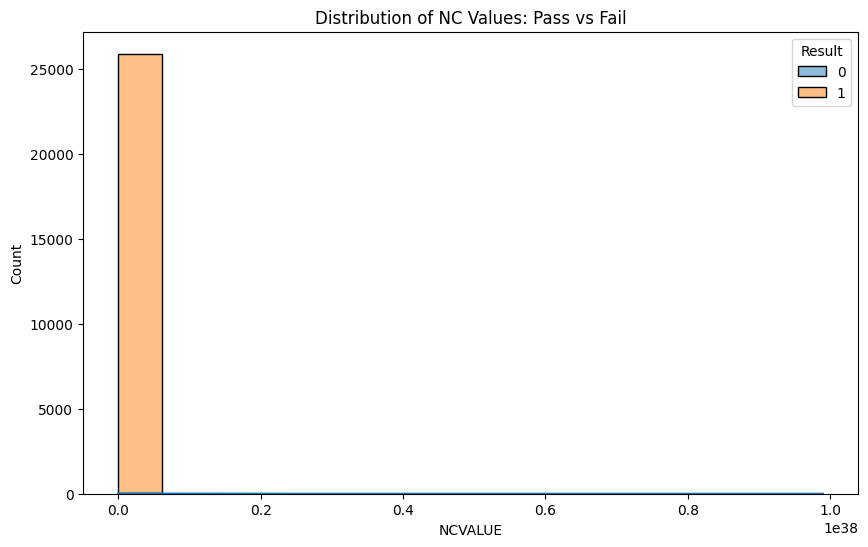

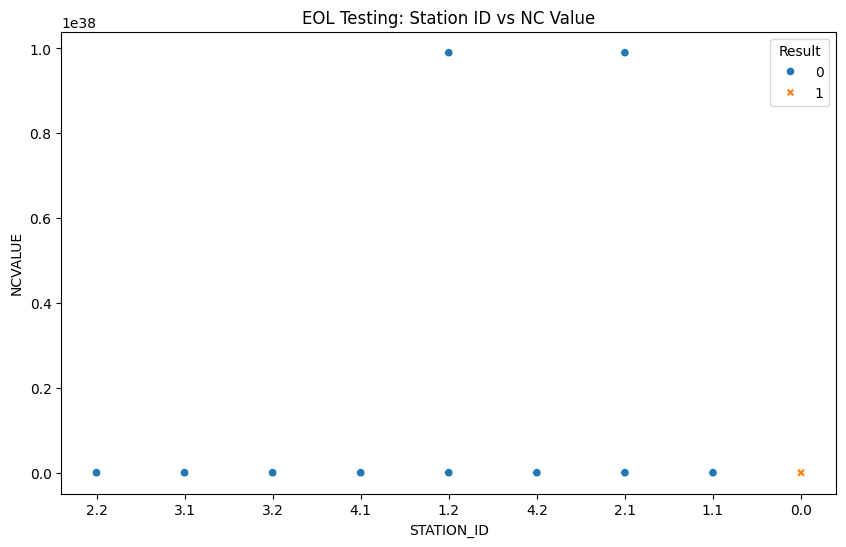

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary copy of df_master to modify 'Result' and 'STATION_ID' for plotting
# without altering the original df_master, which might be used for modeling.
df_plot = df_master.copy()
df_plot['Result'] = df_plot['Result'].astype(str) # Convert 'Result' to string for hue
df_plot['STATION_ID'] = df_plot['STATION_ID'].astype(str) # Convert 'STATION_ID' to string for categorical plotting
df_plot['NCVALUE'] = pd.to_numeric(df_plot['NCVALUE'], errors='coerce').fillna(0.0) # Ensure NCVALUE is numeric (float)

# 1. Histogram of NCVALUEs (Like Figure 1.5)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='NCVALUE', hue='Result', kde=True)
plt.title('Distribution of NC Values: Pass vs Fail')
plt.show()

# 2. Scatterplot of Station ID vs NCVALUE
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='STATION_ID', y='NCVALUE', hue='Result', style='Result')
plt.title('EOL Testing: Station ID vs NC Value')
plt.xlabel('STATION_ID') # Explicitly set x-axis label
plt.show()

### Correlation between STATION_ID and NCVALUE for Failed Tests

Let's calculate the correlation between `STATION_ID` and `NCVALUE` for only the failed tests (`Result = 0`). For this calculation, `STATION_ID` needs to be treated as a numerical value.

In [7]:
# Filter for failed tests (Result = 0)
df_failed = df_master[df_master['Result'] == 0].copy()

# Convert STATION_ID and NCVALUE to numeric, coercing errors
df_failed['STATION_ID_NUM'] = pd.to_numeric(df_failed['STATION_ID'], errors='coerce')
df_failed['NCVALUE_NUM'] = pd.to_numeric(df_failed['NCVALUE'], errors='coerce')

# Drop rows where conversion resulted in NaN (if any)
df_failed_clean = df_failed.dropna(subset=['STATION_ID_NUM', 'NCVALUE_NUM'])

# Calculate the correlation
correlation = df_failed_clean['STATION_ID_NUM'].corr(df_failed_clean['NCVALUE_NUM'])

print(f"Correlation between STATION_ID and NCVALUE for failed tests: {correlation}")

Correlation between STATION_ID and NCVALUE for failed tests: -0.21905534600386425


### Unique STATION_ID Values and Their Counts

Let's examine the unique `STATION_ID` values present in the `df_master` DataFrame and count their occurrences. This helps understand the distribution of tests across different stations.

In [8]:
print("Unique STATION_ID values and their counts:")
display(df_master['STATION_ID'].value_counts())

Unique STATION_ID values and their counts:


,count
STATION_ID,
0.0,25923
2.2,14
2.1,10
3.1,5
3.2,5
4.2,5
1.2,5
4.1,4
1.1,3


### Filtering out `STATION_ID == 0.0` for Failed Tests

Filter out records where `STATION_ID` is `0.0` from failed tests, as these represent completed EOL rather than specific test station failures. Then recalculated the correlation and inspected the remaining unique `STATION_ID` values for failures.

In [9]:
# Filter for failed tests (Result = 0) and exclude STATION_ID == 0.0
df_failed_filtered = df_master[(df_master['Result'] == 0) & (df_master['STATION_ID'] != 0.0)].copy()

# Convert STATION_ID and NCVALUE to numeric, coercing errors
df_failed_filtered['STATION_ID_NUM'] = pd.to_numeric(df_failed_filtered['STATION_ID'], errors='coerce')
df_failed_filtered['NCVALUE_NUM'] = pd.to_numeric(df_failed_filtered['NCVALUE'], errors='coerce')

# Drop rows where conversion resulted in NaN (if any)
df_failed_filtered_clean = df_failed_filtered.dropna(subset=['STATION_ID_NUM', 'NCVALUE_NUM'])

# Calculate the correlation for the filtered data
correlation_filtered = df_failed_filtered_clean['STATION_ID_NUM'].corr(df_failed_filtered_clean['NCVALUE_NUM'])

print(f"Correlation between STATION_ID and NCVALUE for filtered failed tests (excluding 0.0): {correlation_filtered}")

Correlation between STATION_ID and NCVALUE for filtered failed tests (excluding 0.0): -0.21905534600386425


### Unique STATION_ID Values and Their Counts (Filtered for Failures, excluding 0.0)

In [10]:
print("Unique STATION_ID values and their counts in filtered failed tests:")
display(df_failed_filtered['STATION_ID'].value_counts())

Unique STATION_ID values and their counts in filtered failed tests:


,count
STATION_ID,
2.2,14
2.1,10
3.2,5
3.1,5
4.2,5
1.2,5
4.1,4
1.1,3


### Re-training and Re-evaluating the MLP Classifier

The data cleaning and preparation steps,the correct handling of numeric features, it's essential to re-train the `MLPClassifier` with the updated `X_train` and `y_train` datasets. After re-training, we will re-evaluate its performance using the classification report to see if the improvements in data quality have positively impacted the model's ability to classify failed tests.

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Re-initialize the MLP Classifier (using the same parameters as before)
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=2000, random_state=42)

# Re-train the model with the cleaned and prepared data
print("Re-training MLP Classifier...")
mlp.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set with the re-trained model
predictions_retrained = mlp.predict(X_test)

# Print the accuracy score and classification report for the re-trained model
print("\n--- Accuracy Score (Re-trained Model) ---")
print(accuracy_score(y_test, predictions_retrained))

print("\n--- Classification Report (Re-trained Model) ---")
print(classification_report(y_test, predictions_retrained))

Re-training MLP Classifier...
Training complete.

--- Accuracy Score (Re-trained Model) ---
1.0

--- Classification Report (Re-trained Model) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00      5188

    accuracy                           1.00      5195
   macro avg       1.00      1.00      1.00      5195
weighted avg       1.00      1.00      1.00      5195



### Confusion Matrix (Re-trained Model)

In [12]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_retrained = confusion_matrix(y_test, predictions_retrained)

print("--- Confusion Matrix (Re-trained Model) ---")
display(pd.DataFrame(cm_retrained, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

--- Confusion Matrix (Re-trained Model) ---


,Predicted 0,Predicted 1
Actual 0,7,0
Actual 1,0,5188


In [13]:
print("Number of 'Pass' samples (Result=1) in the test set (y_test):")
print(y_test.value_counts()[1])

Number of 'Pass' samples (Result=1) in the test set (y_test):
5188


In [14]:
print("Total number of 'Pass' samples (Result=1) in the original master DataFrame:")
print(df_master['Result'].value_counts()[1])

Total number of 'Pass' samples (Result=1) in the original master DataFrame:
25923


### Analysing the 44 Failures in the Training Set

To understand the characteristics of the failed tests that were used for training the model,filter the original `df_master` for `Result == 0` (failures) and then apply the same `train_test_split` logic to see the distribution of these failures in the training set. Then examine the `STATION_ID` and `NCVALUE` distributions within this specific subset.

In [15]:
# Filter df_master for only failed tests (Result == 0)
df_failures_only = df_master[df_master['Result'] == 0].copy()

# Prepare features (X_failures) and target (y_failures) for these failed tests
X_failures = df_failures_only[features].copy()
for col in features:
    X_failures.loc[:, col] = pd.to_numeric(X_failures[col], errors='coerce')
X_failures = X_failures.fillna(0)
y_failures = df_failures_only['Result']

# Apply the same train_test_split to these failed tests
# This will ensure we correctly identify the failures that landed in the training set
X_failures_train, X_failures_test, y_failures_train, y_failures_test = train_test_split(
    X_failures, y_failures, test_size=0.2, random_state=42
)

print(f"Total failures in original dataset: {len(df_failures_only)}")
print(f"Failures in training set (y_failures_train): {len(y_failures_train)}")
print(f"Failures in test set (y_failures_test): {len(y_failures_test)}")


Total failures in original dataset: 51
Failures in training set (y_failures_train): 40
Failures in test set (y_failures_test): 11


In [16]:
# Actual 'STATION_ID' and 'NCVALUE' for these 44 failures in the training set.
# Indices from y_failures_train to select from the original df_failures_only.

train_failure_indices = y_failures_train.index
df_train_failures = df_failures_only.loc[train_failure_indices]

print("\nSTATION_ID distribution for the 44 failures in the training set:")
display(df_train_failures['STATION_ID'].value_counts())

print("\nNCVALUE distribution for the 44 failures in the training set:")
display(df_train_failures['NCVALUE'].value_counts())



STATION_ID distribution for the 44 failures in the training set:


,count
STATION_ID,
2.2,12
3.1,5
4.2,5
2.1,5
1.2,4
1.1,3
4.1,3
3.2,3



NCVALUE distribution for the 44 failures in the training set:


,count
NCVALUE,
0,25
FALSE,6
9.90E+37,2
2495,1
4095,1
2038,1
0,1
2471,1
2494,1


### Distribution of NCVALUE for Failures in the Training Set

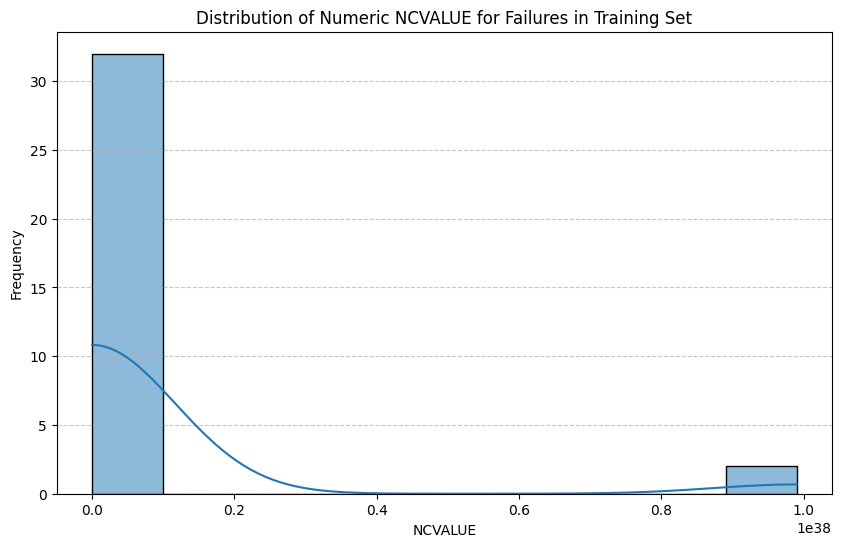


Non-numeric NCVALUEs (excluded from histogram): ['FALSE']


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure NCVALUE is numeric for plotting, coercing errors to NaN
df_train_failures_plot = df_train_failures.copy()
df_train_failures_plot['NCVALUE_numeric'] = pd.to_numeric(df_train_failures_plot['NCVALUE'], errors='coerce')

# Drop NaNs that resulted from non-numeric values for histogram plotting
# We'll handle non-numeric values separately or acknowledge their presence
numeric_ncvalues = df_train_failures_plot.dropna(subset=['NCVALUE_numeric'])['NCVALUE_numeric']

plt.figure(figsize=(10, 6))
sns.histplot(numeric_ncvalues, kde=True, bins=10)
plt.title('Distribution of Numeric NCVALUE for Failures in Training Set')
plt.xlabel('NCVALUE')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Additionally, display non-numeric NCVALUEs if any
non_numeric_ncvalues = df_train_failures_plot[df_train_failures_plot['NCVALUE_numeric'].isna()]['NCVALUE'].unique()
if len(non_numeric_ncvalues) > 0:
    print(f"\nNon-numeric NCVALUEs (excluded from histogram): {non_numeric_ncvalues}")


### Investigating 'FALSE' NCVALUE Entries in Training Set Failures

To understand the context of the 'FALSE' non-numeric values in the `NCVALUE` column for failed tests in the training set, Display the rows where `NCVALUE` is exactly 'FALSE'. This will run a query for the full details of these specific failure records.

In [18]:
# Filter df_train_failures for rows where NCVALUE is 'FALSE'
false_ncvalue_failures = df_train_failures[df_train_failures['NCVALUE'] == 'FALSE']

print("Details of failures in the training set where NCVALUE is 'FALSE':")
display(false_ncvalue_failures)

Details of failures in the training set where NCVALUE is 'FALSE':


,SFC,MAX(EOL_TIME),DAY,HOUR,MATERIAL,RESRCE,FAULT_COMMENT,CALWEEK,NCVALUE,TEST_STEP,...,UPPERLIMIT,STATION_ID,FAIL_INFO,Result,ACTION_CODE,OPERATION,DATE_TIME,DT2,ROUTER,PRODUCTION_ORDER
9,Y2007ZDP00NV6,27/04/2026 11:29,27.0,11.0,12242795,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,4.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
16,Y2007ZDP00KZF,27/04/2026 16:10,27.0,16.0,12242795,200158876,LOGIN,202618.0,FALSE,15.02,...,0,3.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
11,Y2007ZDP00WN2,27/04/2026 10:54,27.0,10.0,12242795,200158876,LOGIN,202618.0,FALSE,15.02,...,0,1.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
27,Y2007ZDP013J1,27/04/2026 23:12,27.0,23.0,12242796,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,2.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
34,Y2007ZDP01E9F,27/04/2026 19:20,27.0,19.0,12242796,200158876,LOGIN,202618.0,FALSE,15.02,...,0,2.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
39,Y2007ZDP01FOG,27/04/2026 22:21,27.0,22.0,12242796,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,1.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0


### Comparing 'KMS_Write_Key' vs 'LOGIN' Failures (NCVALUE = 'FALSE')

Let's separate the records for 'KMS_Write_Key' and 'LOGIN' failures to compare their characteristics.

In [19]:
# Filter for 'KMS_Write_Key' failures
kms_write_key_failures = false_ncvalue_failures[false_ncvalue_failures['FAULT_COMMENT'] == 'KMS_Write_Key']
print("Details for 'KMS_Write_Key' failures:")
display(kms_write_key_failures)

# Filter for 'LOGIN' failures
login_failures = false_ncvalue_failures[false_ncvalue_failures['FAULT_COMMENT'] == 'LOGIN']
print("\nDetails for 'LOGIN' failures:")
display(login_failures)


Details for 'KMS_Write_Key' failures:


,SFC,MAX(EOL_TIME),DAY,HOUR,MATERIAL,RESRCE,FAULT_COMMENT,CALWEEK,NCVALUE,TEST_STEP,...,UPPERLIMIT,STATION_ID,FAIL_INFO,Result,ACTION_CODE,OPERATION,DATE_TIME,DT2,ROUTER,PRODUCTION_ORDER
9,Y2007ZDP00NV6,27/04/2026 11:29,27.0,11.0,12242795,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,4.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
27,Y2007ZDP013J1,27/04/2026 23:12,27.0,23.0,12242796,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,2.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
39,Y2007ZDP01FOG,27/04/2026 22:21,27.0,22.0,12242796,200158876,KMS_Write_Key,202618.0,FALSE,270.01,...,0,1.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0



Details for 'LOGIN' failures:


,SFC,MAX(EOL_TIME),DAY,HOUR,MATERIAL,RESRCE,FAULT_COMMENT,CALWEEK,NCVALUE,TEST_STEP,...,UPPERLIMIT,STATION_ID,FAIL_INFO,Result,ACTION_CODE,OPERATION,DATE_TIME,DT2,ROUTER,PRODUCTION_ORDER
16,Y2007ZDP00KZF,27/04/2026 16:10,27.0,16.0,12242795,200158876,LOGIN,202618.0,FALSE,15.02,...,0,3.2,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
11,Y2007ZDP00WN2,27/04/2026 10:54,27.0,10.0,12242795,200158876,LOGIN,202618.0,FALSE,15.02,...,0,1.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0
34,Y2007ZDP01E9F,27/04/2026 19:20,27.0,19.0,12242796,200158876,LOGIN,202618.0,FALSE,15.02,...,0,2.1,mapping NC: EOL_FAIL,0,0,0,0.0,0,0,0.0


### Bar Chart Comparison of STATION_ID for 'KMS_Write_Key' vs 'LOGIN' Failures

### Material Numbers for 'FALSE' NCVALUE Failures

The `MATERIAL` numbers associated with the failures where `NCVALUE` was identified as 'FALSE'.

In [20]:
# Display the value counts of 'MATERIAL' for false_ncvalue_failures
print("Distribution of MATERIAL for 'FALSE' NCVALUE failures:")
display(false_ncvalue_failures['MATERIAL'].value_counts())

Distribution of MATERIAL for 'FALSE' NCVALUE failures:


,count
MATERIAL,
12242795,3
12242796,3


### Hourly Breakdown of 'FALSE' NCVALUE Failures by Fault Type

Hourly distribution of 'KMS_Write_Key' and 'LOGIN' failures.

In [21]:
# Hourly breakdown for 'KMS_Write_Key' failures
kms_hourly_breakdown = kms_write_key_failures['HOUR'].value_counts().sort_index()
print("Hourly breakdown for 'KMS_Write_Key' failures:")
display(kms_hourly_breakdown)

# Hourly breakdown for 'LOGIN' failures
login_hourly_breakdown = login_failures['HOUR'].value_counts().sort_index()
print("\nHourly breakdown for 'LOGIN' failures:")
display(login_hourly_breakdown)

Hourly breakdown for 'KMS_Write_Key' failures:


,count
HOUR,
11.0,1
22.0,1
23.0,1



Hourly breakdown for 'LOGIN' failures:


,count
HOUR,
10.0,1
16.0,1
19.0,1


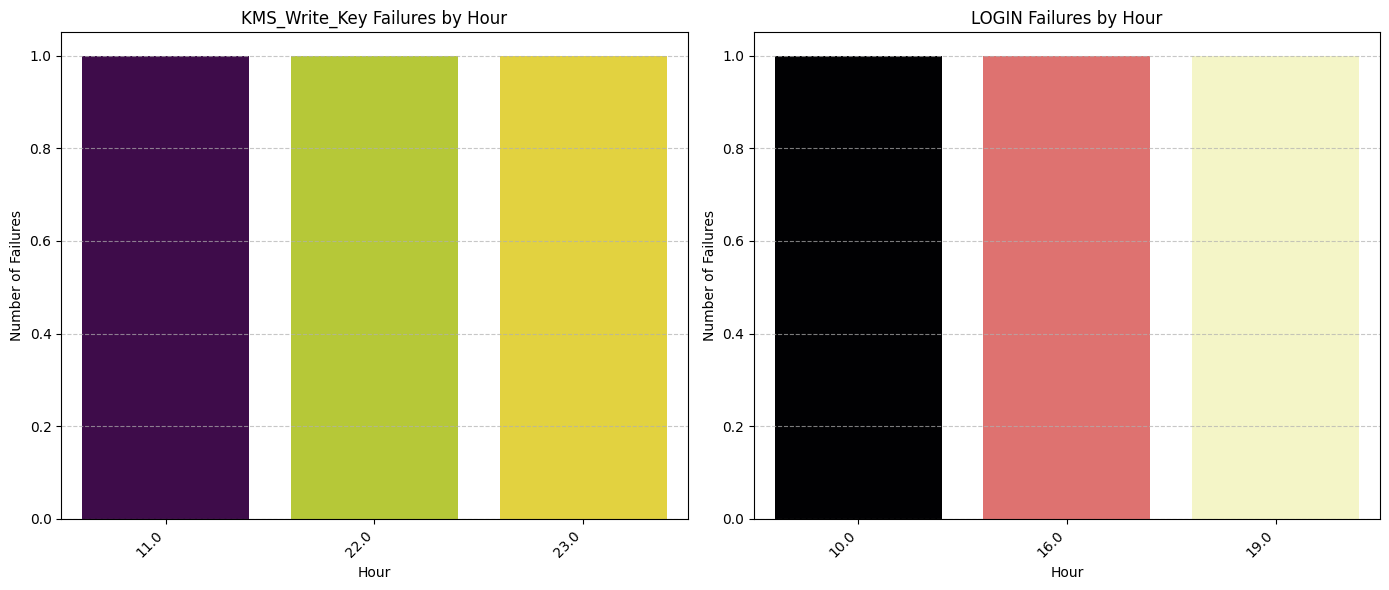

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Subplot 1: KMS_Write_Key Failures by Hour
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x=kms_hourly_breakdown.index, y=kms_hourly_breakdown.values, palette='viridis', hue=kms_hourly_breakdown.index, legend=False)
plt.title("KMS_Write_Key Failures by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: LOGIN Failures by Hour
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x=login_hourly_breakdown.index, y=login_hourly_breakdown.values, palette='magma', hue=login_hourly_breakdown.index, legend=False)
plt.title("LOGIN Failures by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

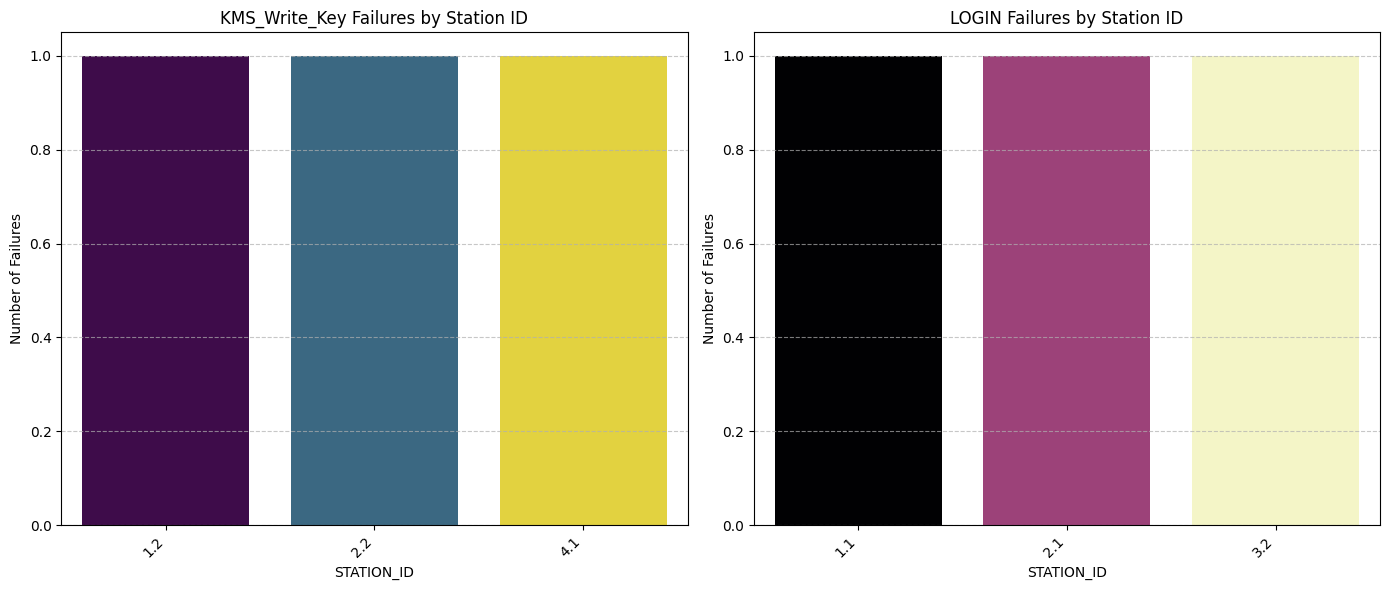

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get STATION_ID counts for KMS_Write_Key failures
kms_station_counts = kms_write_key_failures['STATION_ID'].value_counts().reset_index()
kms_station_counts.columns = ['STATION_ID', 'Count']

# Get STATION_ID counts for LOGIN failures
login_station_counts = login_failures['STATION_ID'].value_counts().reset_index()
login_station_counts.columns = ['STATION_ID', 'Count']

plt.figure(figsize=(14, 6))

# Subplot 1: KMS_Write_Key Failures by STATION_ID
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='STATION_ID', y='Count', data=kms_station_counts, palette='viridis', hue='STATION_ID', legend=False)
plt.title("KMS_Write_Key Failures by Station ID")
plt.xlabel("STATION_ID")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: LOGIN Failures by STATION_ID
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='STATION_ID', y='Count', data=login_station_counts, palette='magma', hue='STATION_ID', legend=False)
plt.title("LOGIN Failures by Station ID")
plt.xlabel("STATION_ID")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Average NCVALUE for Passing vs. Failing Tests

The mean `NCVALUE` for tests that passed (`Result = 1`) and tests that failed (`Result = 0`). This will help ME understand if there's a significant difference in the `NCVALUE` magnitudes between these two outcomes.

In [24]:
# Ensure NCVALUE is numeric for calculations, coercing errors to NaN
df_master['NCVALUE_numeric'] = pd.to_numeric(df_master['NCVALUE'], errors='coerce')

# Calculate average NCVALUE for failing tests (Result = 0)
mean_ncvalue_failed = df_master[df_master['Result'] == 0]['NCVALUE_numeric'].mean()
print(f"Average NCVALUE for failing tests (Result = 0): {mean_ncvalue_failed:.2f}")

# Calculate average NCVALUE for passing tests (Result = 1)
mean_ncvalue_passed = df_master[df_master['Result'] == 1]['NCVALUE_numeric'].mean()
print(f"Average NCVALUE for passing tests (Result = 1): {mean_ncvalue_passed:.2f}")

Average NCVALUE for failing tests (Result = 0): 4499999999999999969531939298566209536.00
Average NCVALUE for passing tests (Result = 1): 0.00


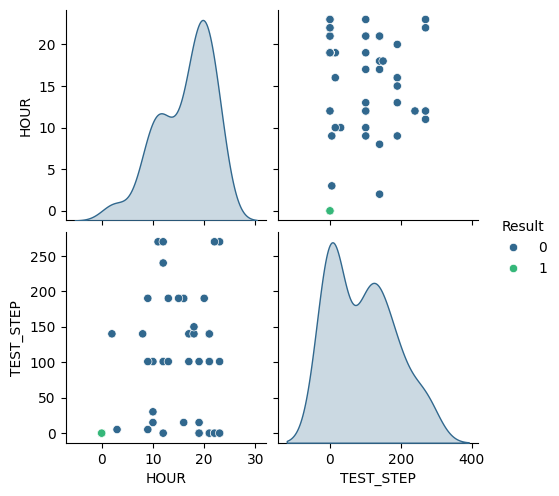

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your specific EOL columns
plot_columns = ['NCVALUE', 'HOUR', 'TEST_STEP', 'Result']

# This generates the multi-grid view
sns.pairplot(df_master[plot_columns], hue='Result', palette='viridis', diag_kind='kde')
plt.show()

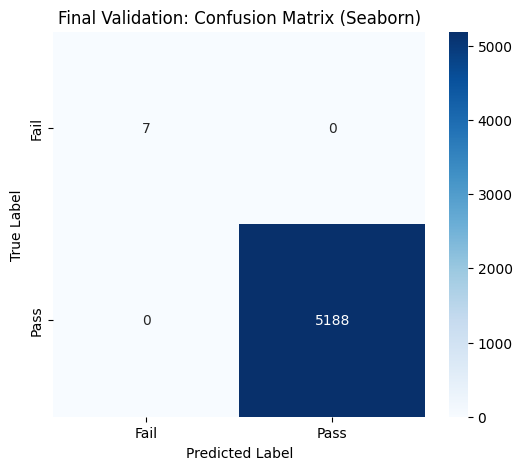

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, predictions)

# Get labels for the confusion matrix
labels = ['Fail', 'Pass']

# Plot it using seaborn.heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Final Validation: Confusion Matrix (Seaborn)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [27]:
import plotly.express as px

# Ensure NCVALUE_numeric is present and used for plotting
# (df_master['NCVALUE_numeric'] was created previously)

# 1. Visualize Drift: NCVALUE over Time
# This shows if the measurements are 'wandering' upwards
fig_drift = px.scatter(df_master, x='HOUR', y='NCVALUE_numeric', color='RESRCE',
                 title='Measurement Drift Analysis over 24 Hours',
                 trendline="lowess")
fig_drift.show()

# 2. Identify the Worst Adapter
# This bar chart shows which resource has the most fails
fail_data = df_master[df_master['Result'] == 0]
fig_fails = px.histogram(fail_data, x='RESRCE', title='Total Failures by Test Adapter/Resource')
fig_fails.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


### Failure Rates by Adapter (RESRCE)

Given that `RESRCE` represents a single machine with 8 adapters, the failure distribution across these unique adapter IDs to identify which ones contribute most to the non-conformance.

In [28]:
# Filter for failed tests (Result = 0)
failed_tests = df_master[df_master['Result'] == 0]

# Count the occurrences of each unique RESRCE (adapter ID)
adapter_failure_counts = failed_tests['RESRCE'].value_counts().reset_index()
adapter_failure_counts.columns = ['RESRCE', 'Failure Count']

# Sort by Failure Count in descending order
adapter_failure_counts = adapter_failure_counts.sort_values(by='Failure Count', ascending=False)

print("Failure counts for each adapter (RESRCE):")
display(adapter_failure_counts)

Failure counts for each adapter (RESRCE):


,RESRCE,Failure Count
0,200158876,51


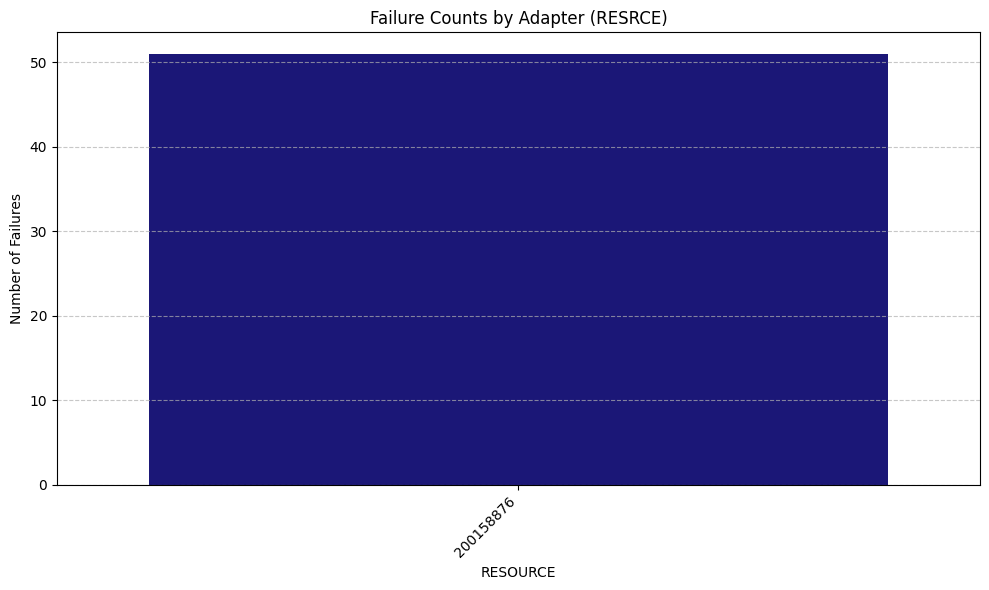

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='RESRCE', y='Failure Count', data=adapter_failure_counts, palette='plasma', hue='RESRCE', legend=False)
plt.title('Failure Counts by Adapter (RESRCE)')
plt.xlabel('RESOURCE')
plt.ylabel('Number of Failures')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

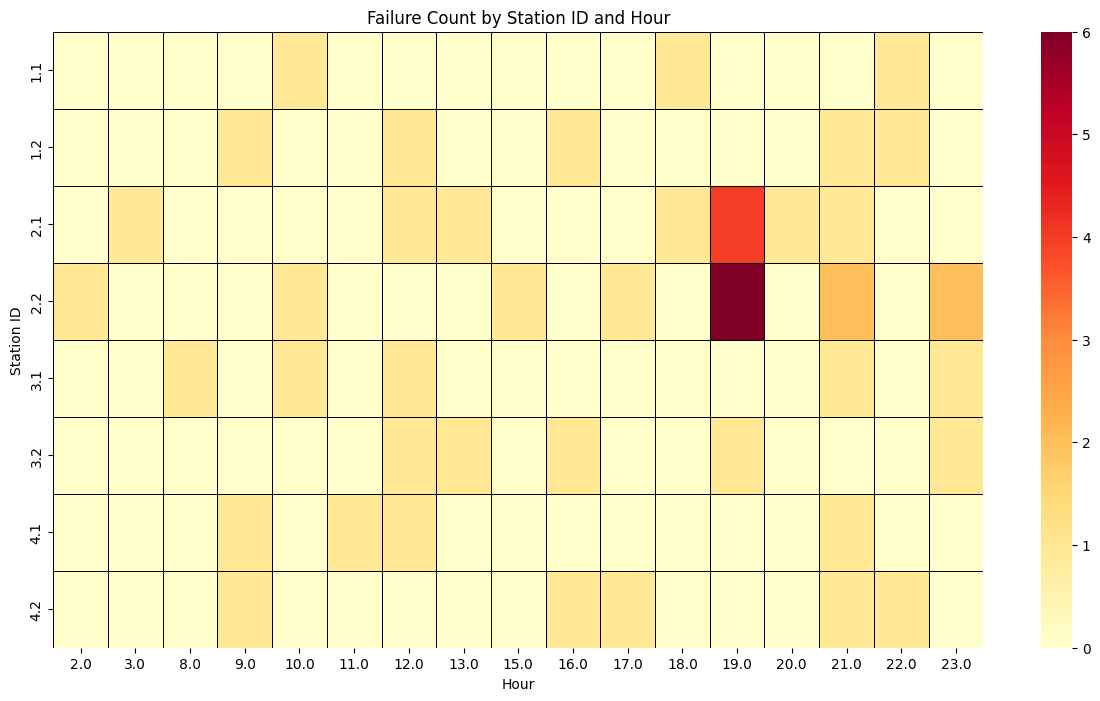

Detailed failure counts by Station ID and Hour:


HOUR,2.0,3.0,8.0,9.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
STATION_ID,,,,,,,,,,,,,,,,,
1.1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
1.2,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0
2.1,0,1,0,0,0,0,1,1,0,0,0,1,4,1,1,0,0
2.2,1,0,0,0,1,0,0,0,1,0,1,0,6,0,2,0,2
3.1,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,1
3.2,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,1
4.1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0
4.2,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1,1,0


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for failed tests (Result = 0)
df_failures = df_master[df_master['Result'] == 0].copy()

# Ensure 'STATION_ID' is treated as a categorical value for grouping/plotting
df_failures['STATION_ID'] = df_failures['STATION_ID'].astype(str)

# Count failures by STATION_ID and HOUR
failures_by_station_hour = df_failures.groupby(['STATION_ID', 'HOUR']).size().unstack(fill_value=0)

# Sort the station IDs for better visualization, if they are numeric strings
# For example, if '1.1', '2.1', '10.1', we want '1.1', '2.1', '10.1' in order.
# Convert back to numeric, sort, then back to string for consistent ordering
station_ids_numeric = pd.to_numeric(failures_by_station_hour.index, errors='coerce').dropna()
sorted_station_ids = station_ids_numeric.sort_values().astype(str)
failures_by_station_hour = failures_by_station_hour.reindex(sorted_station_ids)


plt.figure(figsize=(15, 8))
sns.heatmap(failures_by_station_hour, cmap='YlOrRd', linewidths=.5, linecolor='black')
plt.title('Failure Count by Station ID and Hour')
plt.xlabel('Hour')
plt.ylabel('Station ID')
plt.show()

print("Detailed failure counts by Station ID and Hour:")
display(failures_by_station_hour)

### Top 3 Stations by Failure Frequency

In [31]:
# Calculate total failures per station
total_failures_per_station = failures_by_station_hour.sum(axis=1).sort_values(ascending=False)

print("Top 3 stations by total failure frequency:")
display(total_failures_per_station.head(3))

Top 3 stations by total failure frequency:


,0
STATION_ID,
2.2,14
2.1,10
1.2,5


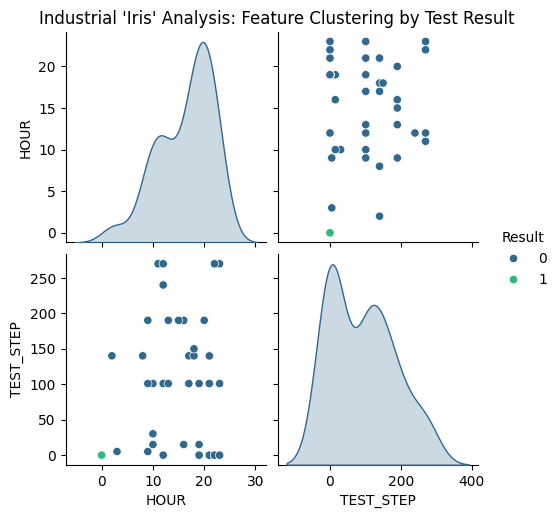

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the columns you want to compare (your "features")
# For your project, these are usually NCVALUE, HOUR, and TEST_STEP
features = ['NCVALUE', 'HOUR', 'TEST_STEP', 'Result']

# 2. Create the Pairplot
# 'hue' is the magic part—it colors the dots by your Result (Pass vs Fail)
sns.pairplot(df_master[features], hue='Result', palette='viridis', diag_kind='kde')

# 3. Add a title and show
plt.suptitle("Industrial 'Iris' Analysis: Feature Clustering by Test Result", y=1.02)
plt.show()

### Visualizing Decision Boundaries for the MLP Classifier (2D Projection)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MLPClassifier was fitted with feature names



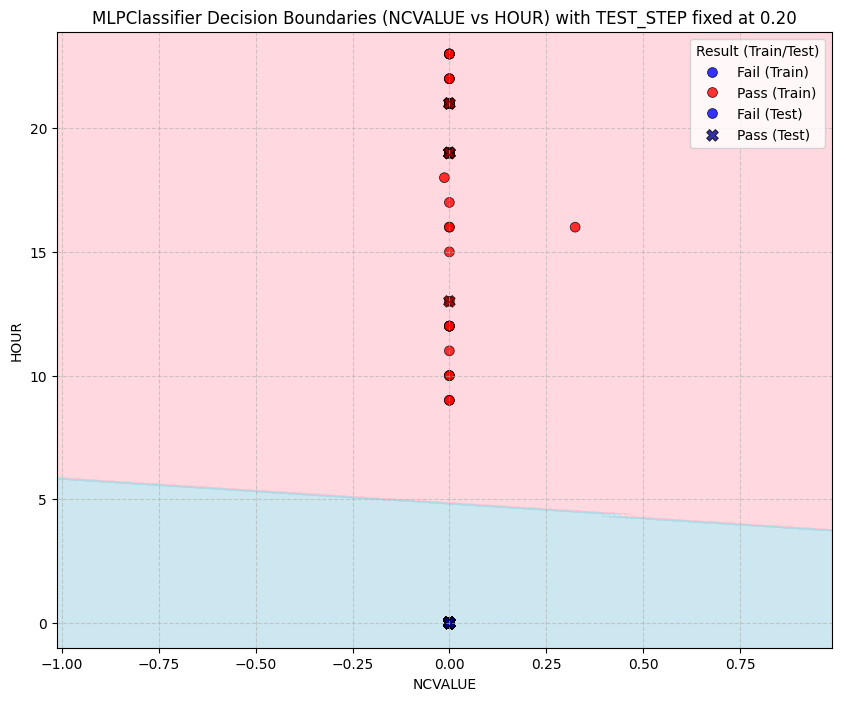

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Assuming X_train, y_train, mlp are already defined and the model is trained

# Select two features for 2D visualization (e.g., NCVALUE and HOUR)
feature1_idx = X_train.columns.get_loc('NCVALUE')
feature2_idx = X_train.columns.get_loc('HOUR')

# For simplicity, we'll fix the third feature (TEST_STEP) at its mean value from the training data
# This creates a 2D slice of the 3D decision boundary
fixed_test_step_value = X_train['TEST_STEP'].mean()

# Create a meshgrid to plot decision boundaries
x_min = X_train.iloc[:, feature1_idx].min() - 1
x_max = X_train.iloc[:, feature1_idx].quantile(0.99) + 1 # Use 99th percentile for robust upper bound
y_min = X_train.iloc[:, feature2_idx].min() - 1
y_max = X_train.iloc[:, feature2_idx].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                       np.arange(y_min, y_max, 0.1))

# Prepare the meshgrid for prediction by adding the fixed TEST_STEP value
# The order of features must match the order used during training (NCVALUE, HOUR, TEST_STEP)

# Create an empty array with the correct number of columns (features)
Z_input = np.zeros((xx.ravel().shape[0], X_train.shape[1]))

# Fill the NCVALUE and HOUR columns with meshgrid values
Z_input[:, feature1_idx] = xx.ravel()
Z_input[:, feature2_idx] = yy.ravel()

# Fill the TEST_STEP column with the fixed mean value
other_feature_idx = X_train.columns.get_loc('TEST_STEP')
Z_input[:, other_feature_idx] = fixed_test_step_value

# Make predictions on the meshgrid
Z = mlp.predict(Z_input)

# Put the result into a color plot
Z = Z.reshape(xx.shape)

# Create color maps
cmp = ListedColormap(['#FFC0CB', '#ADD8E6']) # Pink for Fail (0), Light Blue for Pass (1)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=cmp, alpha=0.6)

# Plot the training points
sns.scatterplot(x=X_train.iloc[:, feature1_idx],
                y=X_train.iloc[:, feature2_idx],
                hue=y_train,
                palette={0: 'red', 1: 'blue'},
                marker='o', s=50, alpha=0.8,
                edgecolor='k', legend='full')

# Plot the test points
sns.scatterplot(x=X_test.iloc[:, feature1_idx],
                y=X_test.iloc[:, feature2_idx],
                hue=y_test,
                palette={0: 'darkred', 1: 'darkblue'},
                marker='X', s=70, alpha=0.8,
                edgecolor='k', legend=False)

plt.title(f'MLPClassifier Decision Boundaries (NCVALUE vs HOUR) with TEST_STEP fixed at {fixed_test_step_value:.2f}')
plt.xlabel(X_train.columns[feature1_idx])
plt.ylabel(X_train.columns[feature2_idx])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.legend(title='Result (Train/Test)', labels=['Fail (Train)', 'Pass (Train)', 'Fail (Test)', 'Pass (Test)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Exploring Misclassified Samples in the Test Set

In [34]:
# Identify misclassified samples
misclassified_indices = y_test[y_test != predictions].index

# Get the features and actual labels for misclassified samples
misclassified_X = X_test.loc[misclassified_indices]
misclassified_y = y_test.loc[misclassified_indices]

# Combine into a DataFrame for easier inspection
misclassified_df = misclassified_X.copy()
misclassified_df['Actual_Result'] = misclassified_y
misclassified_df['Predicted_Result'] = predictions[misclassified_indices.to_numpy() - X_test.index.min()]

# Display the misclassified samples
print(f"Number of misclassified samples: {len(misclassified_df)}")
display(misclassified_df)

Number of misclassified samples: 0


,NCVALUE,HOUR,TEST_STEP,Actual_Result,Predicted_Result


### Model Performance Metrics

In [35]:
from sklearn.metrics import classification_report

print("\n--- Model Performance Metrics ---")
print(classification_report(y_test, predictions))


--- Model Performance Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00      5188

    accuracy                           1.00      5195
   macro avg       1.00      1.00      1.00      5195
weighted avg       1.00      1.00      1.00      5195



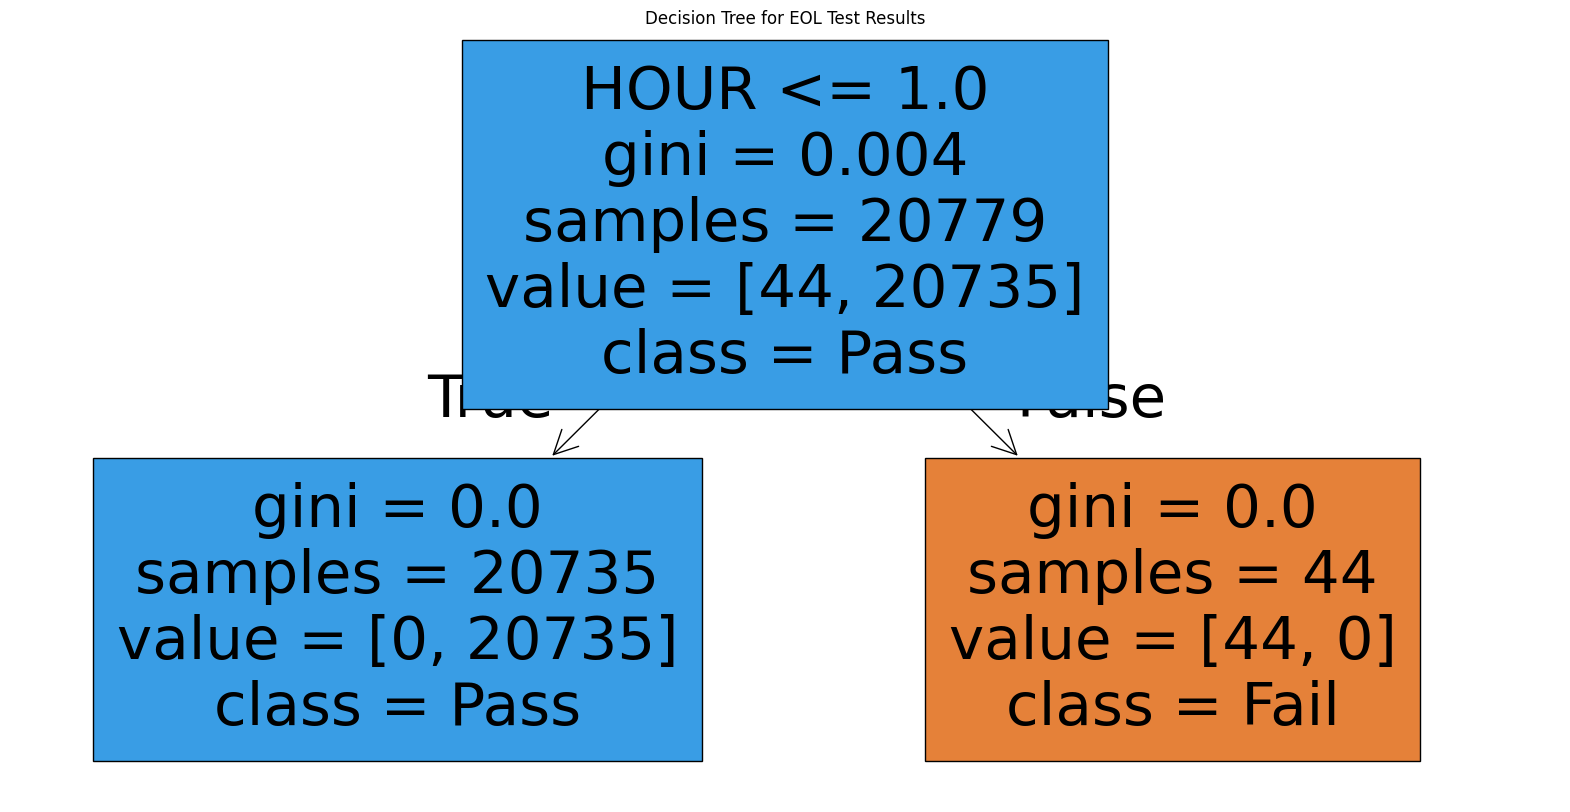

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Initialize and train a Decision Tree Classifier
# Using max_depth to keep the tree readable for visualization
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X_train.columns.tolist(), class_names=['Fail', 'Pass'])
plt.title('Decision Tree for EOL Test Results')
plt.show()

### Feature Importance from Decision Tree

Let's extract and visualize the feature importance scores from the trained Decision Tree. This will indicate which features (NCVALUE, HOUR, TEST_STEP) contributed most to the model's decision-making process.

Feature Importances:


,Feature,Importance
1,HOUR,1.0
0,NCVALUE,0.0
2,TEST_STEP,0.0


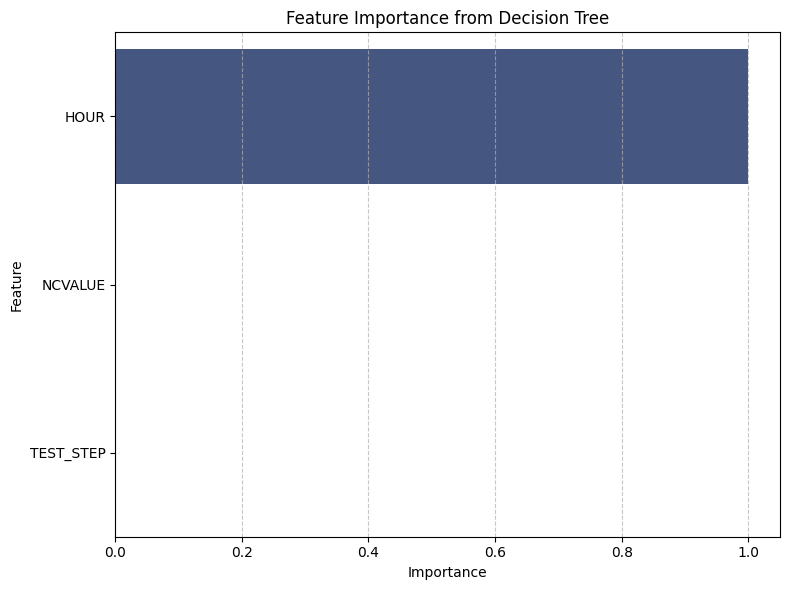

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Decision Tree
feature_importances = dtree.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(features_df)

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Unique `TEST_STEP` Values and Their Counts for Failed Tests

Let's analyze the `TEST_STEP` column specifically for failed tests (`Result = 0`). This will show us which test steps are most common when a product fails.

In [38]:
# Filter for failed tests (Result = 0)
df_failed_test_steps = df_master[df_master['Result'] == 0].copy()

print("Unique TEST_STEP values and their counts for failed tests:")
display(df_failed_test_steps['TEST_STEP'].value_counts())

Unique TEST_STEP values and their counts for failed tests:


,count
TEST_STEP,
0.000,16
101.020,10
270.010,4
190.220,3
15.020,3
140.030,3
140.122,3
240.090,1
5.100,1


K-Means Clustering performed. Cluster assignments:


,count
Cluster,
0,25927
1,47



Cluster assignments compared to actual results:


Result,0,1
Cluster,,
0,4,25923
1,47,0



Generating pairplot for K-Means clusters...


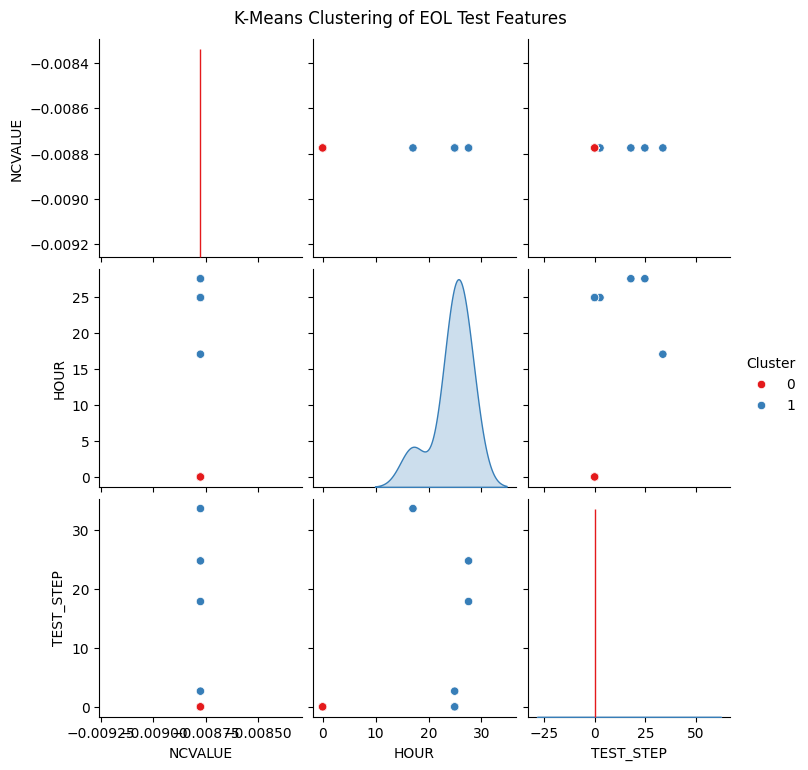


Generating pairplot for actual results...


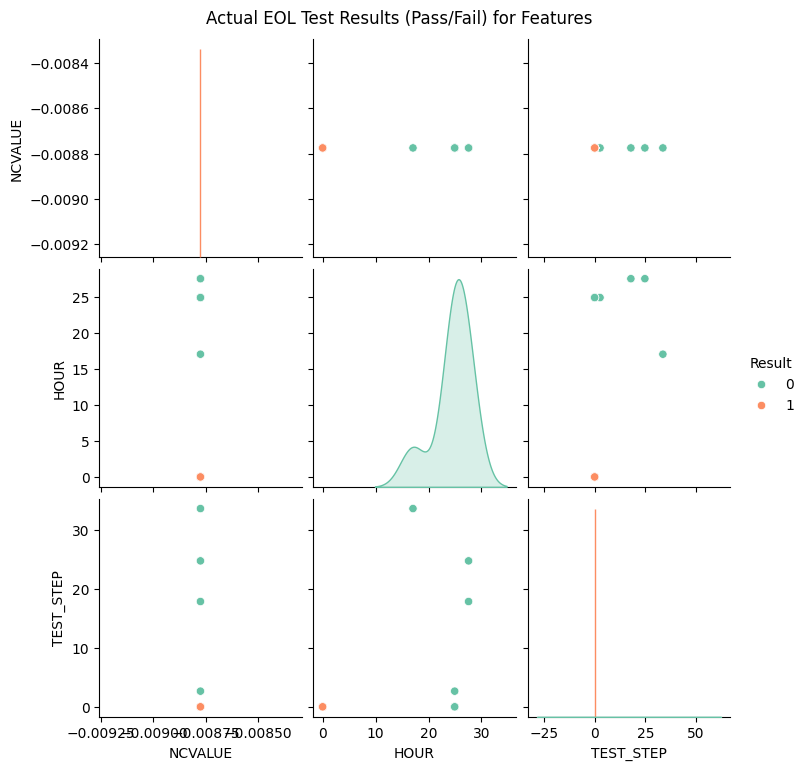

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the features (using the same 'X' as before)
# We'll scale the features first, as K-Means is sensitive to feature scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection and plotting
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# 2. Apply K-Means Clustering
# We'll try to find 2 clusters (Pass/Fail) similar to the Iris binary classification
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled_df)

# Add the cluster labels to our scaled DataFrame
X_scaled_df['Cluster'] = kmeans.labels_
X_scaled_df['Result'] = y # Also add the actual results for comparison

print("K-Means Clustering performed. Cluster assignments:")
display(X_scaled_df['Cluster'].value_counts())
print("\nCluster assignments compared to actual results:")
display(pd.crosstab(X_scaled_df['Cluster'], X_scaled_df['Result']))

# 3. Visualize the Clusters (similar to Iris petal/sepal plots)
# Using a pairplot to see relationships between features and clusters
# This might take a moment to generate due to the number of data points.

print("\nGenerating pairplot for K-Means clusters...")
sns.pairplot(X_scaled_df.sample(n=min(5000, len(X_scaled_df)), random_state=42), # Sample for faster plotting if data is large
             vars=X.columns, hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle('K-Means Clustering of EOL Test Features', y=1.02)
plt.show()

print("\nGenerating pairplot for actual results...")
sns.pairplot(X_scaled_df.sample(n=min(5000, len(X_scaled_df)), random_state=42), # Sample for faster plotting if data is large
             vars=X.columns, hue='Result', palette='Set2', diag_kind='kde')
plt.suptitle('Actual EOL Test Results (Pass/Fail) for Features', y=1.02)
plt.show()

Distribution of failures by hour of day:


,count
EOL_HOUR,
2,1
3,1
8,1
9,3
10,3
11,1
12,5
13,2
15,1



Distribution of failures by day of week:


,count
EOL_DAYOFWEEK,
0,51


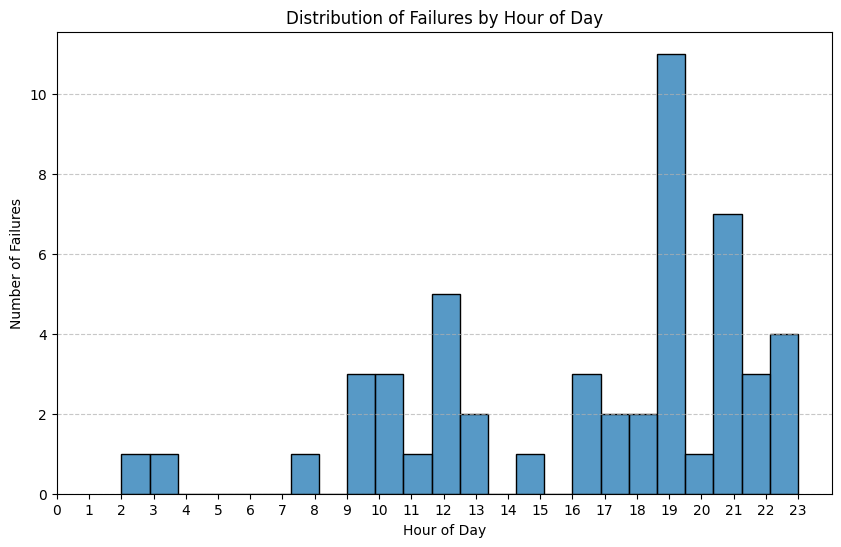

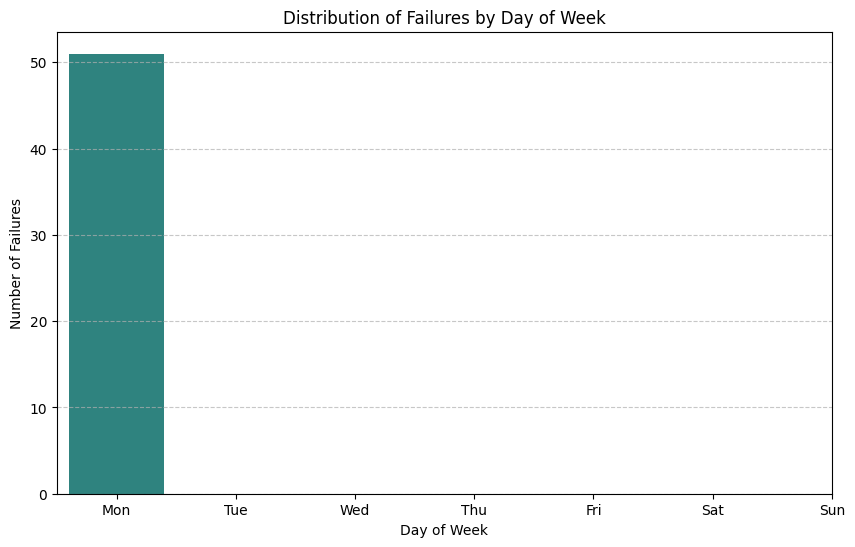

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for failed tests (Result = 0)
df_failures = df_master[df_master['Result'] == 0].copy()

# Convert 'MAX(EOL_TIME)' to datetime objects, handling potential errors
df_failures['EOL_DATETIME'] = pd.to_datetime(df_failures['MAX(EOL_TIME)'], errors='coerce', format='%d/%m/%Y %H:%M')

# Drop rows where datetime conversion failed
df_failures.dropna(subset=['EOL_DATETIME'], inplace=True)

# Extract hour and day of week for potential patterns
df_failures['EOL_HOUR'] = df_failures['EOL_DATETIME'].dt.hour
df_failures['EOL_DAYOFWEEK'] = df_failures['EOL_DATETIME'].dt.dayofweek # Monday=0, Sunday=6

print("Distribution of failures by hour of day:")
display(df_failures['EOL_HOUR'].value_counts().sort_index())

print("\nDistribution of failures by day of week:")
display(df_failures['EOL_DAYOFWEEK'].value_counts().sort_index())

# Visualize failure distribution by hour
plt.figure(figsize=(10, 6))
sns.histplot(df_failures['EOL_HOUR'], bins=24, kde=False)
plt.title('Distribution of Failures by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Failures')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize failure distribution by day of week
plt.figure(figsize=(10, 6))
sns.countplot(x=df_failures['EOL_DAYOFWEEK'], palette='viridis', hue=df_failures['EOL_DAYOFWEEK'], legend=False)
plt.title('Distribution of Failures by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Failures')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [41]:
import pandas as pd

# Filter for failed tests (Result = 0)
df_failures_sfc = df_master[df_master['Result'] == 0].copy()

# Define columns to check for duplicates: HOUR and SFC
duplicate_check_columns = ['HOUR', 'SFC']

# Identify duplicate failures based on HOUR and SFC
duplicate_failures = df_failures_sfc[df_failures_sfc.duplicated(subset=duplicate_check_columns, keep=False)].sort_values(by=duplicate_check_columns)

print(f"Number of duplicate failure records (same hour, same SFC): {len(duplicate_failures)}")

if not duplicate_failures.empty:
    print("\nDetails of duplicate failure records:")
    display(duplicate_failures)
else:
    print("No duplicate failure records found with the same hour and SFC.")

Number of duplicate failure records (same hour, same SFC): 0
No duplicate failure records found with the same hour and SFC.


In [42]:
# Filter for failed tests (Result = 0)
df_failures_sfc_analysis = df_master[df_master['Result'] == 0].copy()

print("Unique SFC values and their counts for failed tests:")
display(df_failures_sfc_analysis['SFC'].value_counts())

Unique SFC values and their counts for failed tests:


,count
SFC,
Y2007ZDP005DC,1
Y2007ZDP00AU5,1
Y2007ZDP00BVG,1
Y2007ZDP00D08,1
Y2007ZDP00HPB,1
Y2007ZDP00L14,1
Y2007ZDP00MI1,1
Y2007ZDP00MP5,1
Y2007ZDP00NBF,1
